<a href="https://colab.research.google.com/github/fboldt/aulasann/blob/main/aula03d%20-%20XOR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

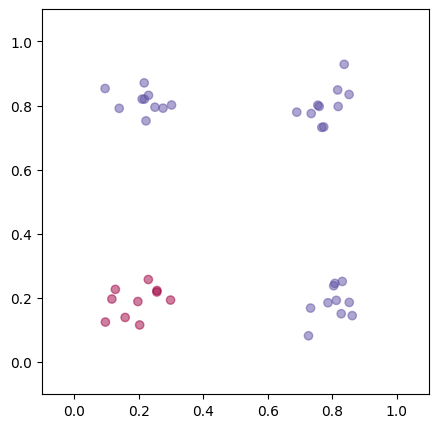

In [169]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

def createLogicalDataset(n=40, func= lambda a, b: bool(a) or bool(b)):
  X, y = make_blobs(n_samples=n,
                    centers=[[0.2,0.2], [0.8, 0.2], [0.2, 0.8], [0.8, 0.8]],
                    n_features=2,
                    cluster_std=0.05,
                    center_box=(0,1))
  y = np.array([func(a>0.5, b>0.5) for a, b in X], dtype=int)
  return X, y

def plotDataset(X, y):
  plt.figure(figsize=(5,5))
  plt.scatter(X[:,0], X[:,1], c=y, cmap="Spectral", alpha=0.5)
  plt.xlim(-0.1,1.1)
  plt.ylim(-0.1,1.1)

def plotHyperplan(vector, intercept, legend="Hyperplan"):
  xs = np.array([0,1])
  ys = -(vector[0]*xs + intercept)/vector[1]
  plt.plot(xs, ys, label=legend)
  plt.legend()

X, y = createLogicalDataset()
plotDataset(X, y)
plt.show()

In [170]:
from abc import ABC, abstractstaticmethod

class CostFunction(ABC):
  @abstractstaticmethod
  def get_cost(y, y_pred):
    pass
  @abstractstaticmethod
  def get_gradient(X, y, y_pred):
    pass

class WidrowHoff(CostFunction):
  @staticmethod
  def get_cost(y, y_pred):
    return np.mean((y-y_pred)**2)
  @staticmethod
  def get_gradient(X, y, y_pred):
    return X.T @ (y-y_pred)

In [171]:
from abc import ABC, abstractmethod

class TrainingAlgorithm(ABC):
  @abstractmethod
  def get_w(self, X, y):
    pass

class SGD(TrainingAlgorithm):
  def __init__(self, max_iter=1000, learning_rate=0.01, cost_function=WidrowHoff()):
    self.max_iter = max_iter
    self.learning_rate = learning_rate
    self.cost_function = cost_function

  def get_w(self, X, y):
    self.w_ = np.random.random(size=X.shape[1])
    for _ in range(self.max_iter):
      y_pred = X @ self.w_
      error = y - y_pred
      self.w_ += self.learning_rate * self.cost_function.get_gradient(X, y, y_pred)
    return self.w_

Accuracy: 1.0
Weights: [-1.13816859  1.71631372  1.57284114]


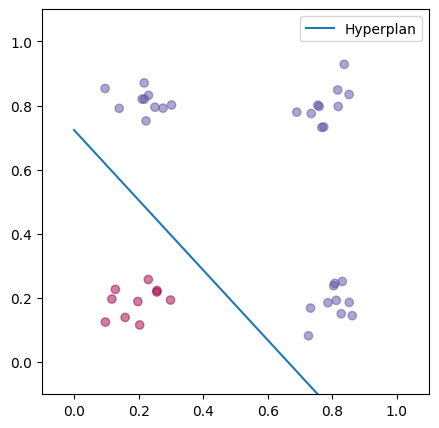

In [172]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import accuracy_score

def include_bias(X):
  return np.hstack((np.ones((X.shape[0],1)), X))

class NeuralNetwork(BaseEstimator, ClassifierMixin):
  def __init__(self, training_algorithm=SGD()):
    self.training_algorithm = training_algorithm

  def fit(self, X, y):
    y = y*2-1
    X = include_bias(X)
    self.w_ = self.training_algorithm.get_w(X, y)
    return self

  def predict(self, X):
    X = include_bias(X)
    logits = X @ self.w_
    y_pred = np.sign(logits)
    return (y_pred+1)/2

model = NeuralNetwork()
model.fit(X, y)
y_pred = model.predict(X)
print(f"Accuracy: {accuracy_score(y, y_pred)}")
print(f"Weights: {model.w_}")
plotDataset(X, y)
plotHyperplan(model.w_[1:], model.w_[0], legend="Hyperplan")
plt.show()

Accuracy: 1.0
Weights: [-2.16170572  1.55344438  1.78973011]


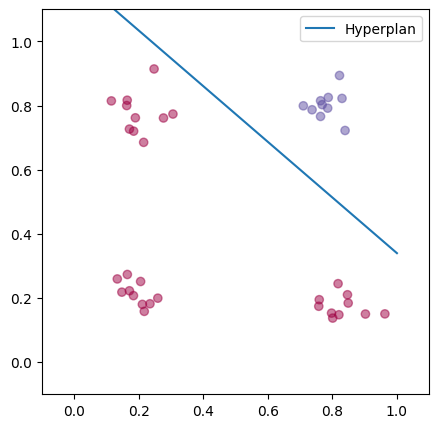

In [173]:
X, y = createLogicalDataset(func= lambda a, b: bool(a) and bool(b))
model = NeuralNetwork()
model.fit(X, y)
y_pred = model.predict(X)
print(f"Accuracy: {accuracy_score(y, y_pred)}")
print(f"Weights: {model.w_}")
plotDataset(X, y)
plotHyperplan(model.w_[1:], model.w_[0], legend="Hyperplan")
plt.show()

Accuracy: 0.5
Weights: [ 0.00630154 -0.01109691 -0.00153904]


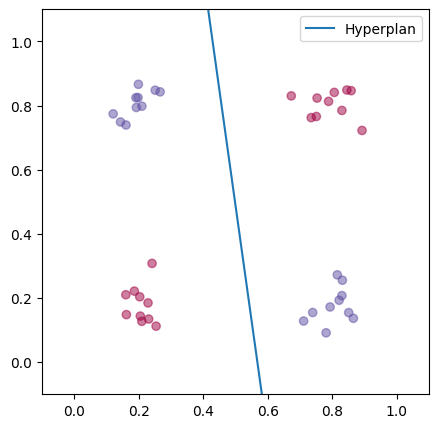

In [174]:
X, y = createLogicalDataset(func= lambda a, b: bool(a) != bool(b))
model = NeuralNetwork()
model.fit(X, y)
y_pred = model.predict(X)
print(f"Accuracy: {accuracy_score(y, y_pred)}")
print(f"Weights: {model.w_}")
plotDataset(X, y)
plotHyperplan(model.w_[1:], model.w_[0], legend="Hyperplan")
plt.show()